In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from RRAM_VISA_Drivers import ITC_1T1R_32x8_switched

driver = ITC_1T1R_32x8_switched(
    B2902B_1_address='',
    B2902B_2_address='',
    Switch_address=''
)

Switch unit init success
ITC_1T1R_32x8_switched init success


In [31]:
driver.disconnect()

(True, 'VISA-instruments were disconnected')

In [ ]:
CELLS = {
    'wl': [0, 1],
    'bl': 0
}

/tmp/ipykernel_322345/2943998103.py:25: RuntimeWarning: invalid value encountered in divide
  axs[i].plot(vol_array, vol_array / R[i], lw=2)


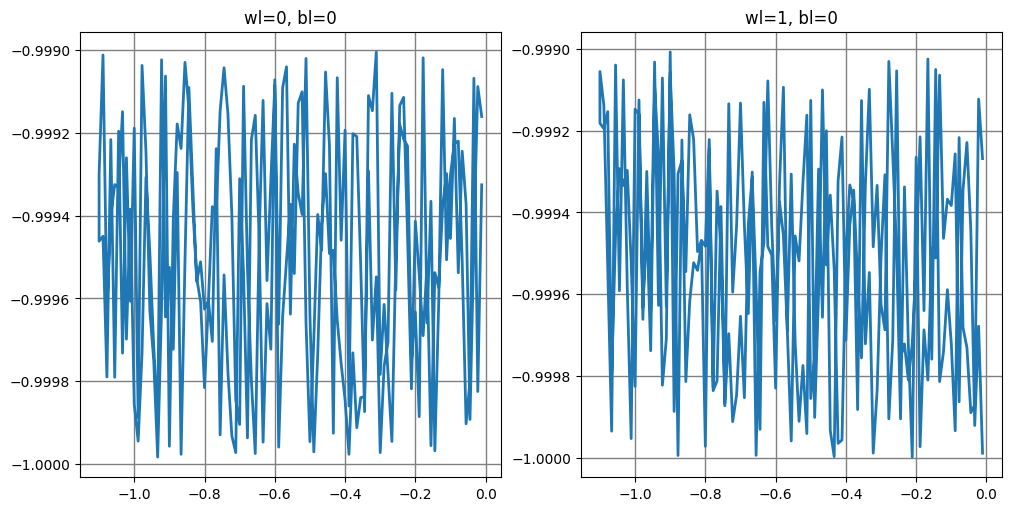

In [ ]:
def reset_cells(voltage = 1.1, plot=True):
    bl = CELLS['bl']
    R = []
    for wl in CELLS['wl']:
        driver.connect_cell(wl, bl)
        n_points = 100
        driver.config_iv_dc(
            trigger_interval=1e-4,
            v_start=0,
            v_stop=abs(voltage),
            n_points=n_points,
            double=True,
            current_compliance=100e-3,  # 100 mA
            sign=1  # BL
        )
        vol_array = np.hstack((np.linspace(0, -abs(voltage), n_points), 
                               np.linspace(-abs(voltage), 0, n_points)))
        result = []
        for vol in vol_array:
            result.append(driver.sense(vol=vol)[0])
        R.append(np.array(result))
    driver.standby()
    if plot:
        _, axs = plt.subplots(nrows=1, ncols=2, layout='constrained', figsize=(10, 5))
        for i, wl in enumerate(CELLS['wl']):
            axs[i].plot(vol_array, vol_array / R[i], lw=2)
            axs[i].grid(color='grey', lw=1, ls='-')
            axs[i].set_title(f'wl={wl}, bl={bl}')
    # return R
        
        
reset_cells()

/tmp/ipykernel_322345/1505926835.py:22: RuntimeWarning: invalid value encountered in divide
  ax.plot(vol_array, vol_array / R, lw=2)


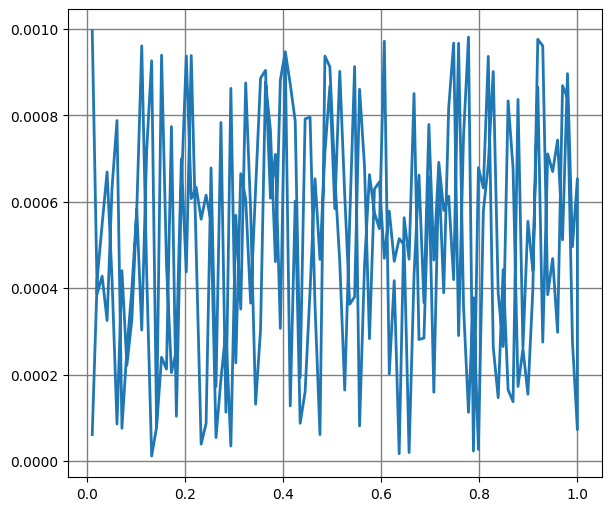

In [8]:
def set_parallel(voltage = 1, compliance=300e-6, plot=True):
    driver.connect_multiple_cells(wl=CELLS['wl'], bl=[CELLS['bl']])
    n_points = 100
    driver.config_iv_dc(
        trigger_interval=1e-4,
        v_start=0,
        v_stop=abs(voltage),
        n_points=n_points,
        double=True,
        current_compliance=compliance,
        sign=0  # NL
    )
    vol_array = np.hstack((np.linspace(0, abs(voltage), n_points), 
                            np.linspace(abs(voltage), 0, n_points)))
    result = []
    for vol in vol_array:
        result.append(driver.sense(vol=vol)[0])
    R = np.array(result)
    driver.standby()
    if plot:
        _, ax = plt.subplots(layout='constrained', figsize=(6, 5))
        ax.plot(vol_array, vol_array / R, lw=2)
        ax.grid(color='grey', lw=1, ls='-')
        
set_parallel()

In [30]:
def read_resistances():
    bl = CELLS['bl']
    R = []
    for wl in CELLS['wl']:
        driver.connect_cell(wl, bl)
        flag, response = driver.config_std(
            pulse_width = 100e-6,
            pulse_sequence = [0.2],
            read_flags = [True],
            current_compliance = 100e-3,
            sign = 1
        )
        R.append(driver.sense(vol=-0.2)[0])
    driver.standby()
    print(R)
    
read_resistances()

[np.float64(0.2000882389133608), np.float64(0.200133549117326)]
